# Phase 3 — Transformer léger sur FD001

Objectif : entraîner un encodeur Transformer léger (`TransformerRULRegressor`) sur exactement
le même pipeline que le LSTM (`05_lstm_fd001.ipynb` : même split seed=42, mêmes 14 capteurs,
même plafond RUL=125, même fenêtre de 30 cycles), et comparer ses scores à la régression
linéaire, la forêt aléatoire et le LSTM déjà obtenus.

Critère « fait » (plan d'exécution, Phase 3) : scores sur le val, comparaison aux modèles
précédents.

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import pandas as pd
import torch

from src.metrics import asymmetric_score, rmse
from src.preprocessing import add_piecewise_rul, compute_norm_stats, make_windows, normalize, select_features, split_by_unit
from src.torch_model import TransformerRULRegressor, set_seed, train_model

SEED = 42
WINDOW_SIZE = 30
RUL_CAP = 125

DATA_DIR = "../DATA/CMaps"
INDEX_NAMES = ["unit_number", "time_cycles"]
SETTING_NAMES = ["setting_1", "setting_2", "setting_3"]
SENSOR_NAMES = [f"sensor_{i}" for i in range(1, 22)]
COL_NAMES = INDEX_NAMES + SETTING_NAMES + SENSOR_NAMES

raw = pd.read_csv(f"{DATA_DIR}/train_FD001.txt", sep=r"\s+", header=None)
raw = raw.iloc[:, : len(COL_NAMES)]
raw.columns = COL_NAMES

train_raw, val_raw = split_by_unit(raw, val_fraction=0.2, seed=SEED)
selected_sensors = select_features(train_raw, SENSOR_NAMES, std_threshold=1e-2)
norm_stats = compute_norm_stats(train_raw, selected_sensors)

train_norm = normalize(train_raw, selected_sensors, norm_stats)
val_norm = normalize(val_raw, selected_sensors, norm_stats)

train_rul = add_piecewise_rul(train_norm, cap=RUL_CAP)
val_rul = add_piecewise_rul(val_norm, cap=RUL_CAP)

X_train, y_train, _ = make_windows(train_rul, selected_sensors, window_size=WINDOW_SIZE, target_col="RUL")
X_val, y_val, _ = make_windows(val_rul, selected_sensors, window_size=WINDOW_SIZE, target_col="RUL")

X_train.shape, X_val.shape

((14459, 30, 14), (3272, 30, 14))

In [2]:
set_seed(SEED)  # avant la construction du modèle : l'initialisation des poids en dépend
model = TransformerRULRegressor(n_features=len(selected_sensors), window_size=WINDOW_SIZE, d_model=64, nhead=4, num_layers=1)

model, history = train_model(model, X_train, y_train, X_val, y_val, epochs=50, lr=1e-3, batch_size=64, seed=SEED)
history_df = pd.DataFrame(history)
history_df.tail()

,epoch,train_loss,val_rmse
45,45,57.160151,15.471649
46,46,52.796397,15.639455
47,47,54.143906,15.756325
48,48,53.729017,15.999312
49,49,53.058974,14.999139


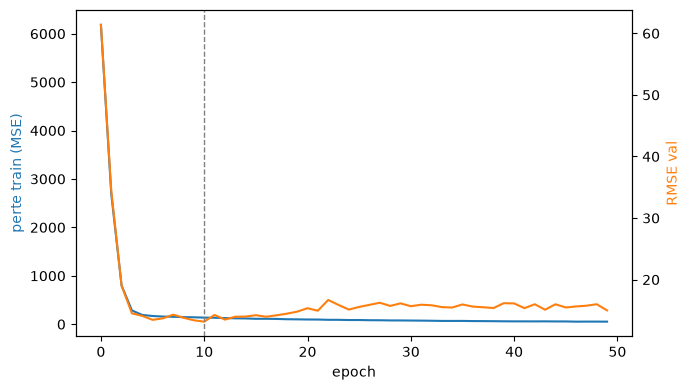

In [3]:
best_epoch = history_df["val_rmse"].idxmin()

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(history_df["epoch"], history_df["train_loss"], color="tab:blue", label="perte train (MSE)")
ax1.set_xlabel("epoch")
ax1.set_ylabel("perte train (MSE)", color="tab:blue")

ax2 = ax1.twinx()
ax2.plot(history_df["epoch"], history_df["val_rmse"], color="tab:orange", label="RMSE val")
ax2.set_ylabel("RMSE val", color="tab:orange")
ax2.axvline(best_epoch, color="grey", linestyle="--", linewidth=1)

fig.tight_layout()

**Ce que montre cette figure** : même lecture que pour le LSTM (`05_lstm_fd001.ipynb`) — perte
train (bleu) qui doit baisser régulièrement, RMSE val (orange) qui doit se stabiliser ou
remonter après un certain point (surapprentissage), ligne pointillée = epoch retenu. Une
architecture à base d'attention peut converger différemment d'un LSTM (parfois plus vite,
parfois plus lentement selon le nombre de paramètres) — c'est justement ce qu'on regarde ici
avant de comparer les scores finaux.

In [4]:
model.eval()
with torch.no_grad():
    device = next(model.parameters()).device
    y_pred = model(torch.tensor(X_val, dtype=torch.float32, device=device)).cpu().numpy()

# Scores des autres modèles, obtenus dans 04_baseline_fd001.ipynb / 05_lstm_fd001.ipynb (même
# split, même seed) : recopiés ici pour comparaison directe, pas recalculés.
comparison = pd.DataFrame([
    {"modèle": "Régression linéaire", "RMSE": 21.536573, "score_asymétrique": 77665.928021},
    {"modèle": "Forêt aléatoire", "RMSE": 17.899715, "score_asymétrique": 29640.942003},
    {"modèle": "LSTM", "RMSE": 13.088298, "score_asymétrique": 12245.140782},
    {"modèle": "Transformer", "RMSE": rmse(y_val, y_pred), "score_asymétrique": asymmetric_score(y_val, y_pred)},
])
comparison

,modèle,RMSE,score_asymétrique
0,Régression linéaire,21.536573,77665.928021
1,Forêt aléatoire,17.899715,29640.942003
2,LSTM,13.088298,12245.140782
3,Transformer,13.167391,11923.526820


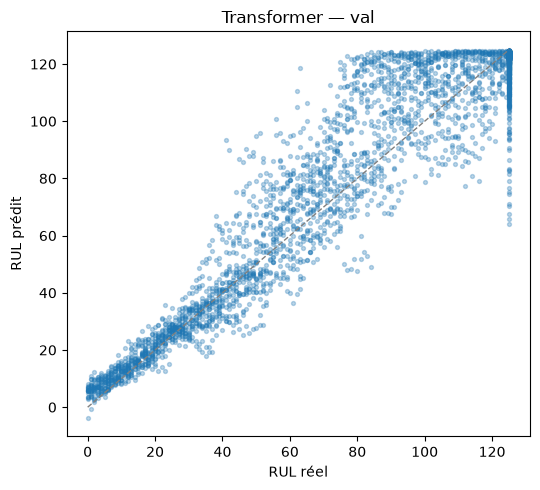

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(y_val, y_pred, s=8, alpha=0.3)
ax.plot([0, RUL_CAP], [0, RUL_CAP], color="grey", linestyle="--", linewidth=1)
ax.set_xlabel("RUL réel")
ax.set_ylabel("RUL prédit")
ax.set_title("Transformer — val")
fig.tight_layout()

**Ce que montre cette figure** : même lecture que pour les autres modèles — proximité à la
diagonale = bonne prédiction. À comparer visuellement au nuage de points du LSTM
(`05_lstm_fd001.ipynb`) pour juger si l'attention capture la dynamique de dégradation aussi
bien, mieux, ou moins bien qu'une mémoire récurrente sur ce jeu de données précis.